# OrbitalWatch Vision — Classificação de Imagens Satelitais


O **OrbitalWatch** é uma plataforma de monitoramento territorial que transforma dados orbitais em informações acionáveis. Este módulo resolve um problema de **classificação de imagens**: identificar automaticamente o tipo de cobertura do solo (urbano, vegetação, água, agricultura, etc.) a partir de imagens do satélite **Sentinel-2**.

Essa classificação alimenta alertas ambientais, mapas de uso do solo e apoio à decisão em operações de sensoriamento remoto — conectando **Visão Computacional** ao contexto da **Indústria Espacial**.


## 1. Definição do problema

| Item | Descrição |
|------|-----------|
| **Tarefa** | Classificação supervisionada multi-classe de imagens RGB |
| **Entrada** | Recortes satelitais (64×64 px) |
| **Saída** | Uma entre 10 classes de cobertura/uso do solo |
| **Técnica** | Duas CNNs implementadas do zero (sem transfer learning) |
| **Meta** | Acurácia ≥ 88% no conjunto de teste |

O problema está ligado ao OrbitalWatch porque a classificação automática reduz o tempo de análise manual de cenas orbitais e padroniza a detecção de mudanças no território monitorado.


## 2. Dataset EuroSAT

| Atributo | Valor |
|----------|-------|
| **Origem** | [EuroSAT](https://github.com/phelber/EuroSAT) — Sentinel-2, RGB |
| **Classes** | 10 categorias de cobertura terrestre |
| **Total** | ~27.000 imagens (pasta `2750/`) |
| **Divisão** | 70% treino · 15% validação · 15% teste (`eurosat.py`, seed=42) |
| **Pré-processamento** | Redimensionamento 64×64, escala 1/255 nas CNNs, `RandomFlip` no treino |

O split estratificado por classe foi gerado com `python eurosat.py`, copiando imagens para `dataset_eurosat/{train,val,test}/`.


In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Image, display, Markdown
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import load_datasets
from src.models import build_simple_cnn, build_deep_cnn

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "outputs" / ".matplotlib"))

%matplotlib inline


In [2]:
DATASET_PATH = ROOT / "dataset_eurosat"
MODELS_DIR = ROOT / "models"
OUTPUTS_DIR = ROOT / "outputs"

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 5e-4
SEED = 42

# False: carrega pesos já treinados (rápido, reproduz entrega)
# True: treina novamente as duas CNNs do zero (~demorado)
TRAIN_MODELS = False

OUTPUTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
tf.keras.utils.set_random_seed(SEED)


In [3]:
def count_images_by_split(dataset_root: Path) -> pd.DataFrame:
    rows = []
    for split in ("train", "val", "test"):
        split_dir = dataset_root / split
        for class_dir in sorted(split_dir.iterdir()):
            if class_dir.is_dir():
                n = len([p for p in class_dir.iterdir() if p.is_file()])
                rows.append({"split": split, "classe": class_dir.name, "imagens": n})
    return pd.DataFrame(rows)

stats = count_images_by_split(DATASET_PATH)
pivot = stats.pivot(index="classe", columns="split", values="imagens").fillna(0).astype(int)
pivot["total"] = pivot.sum(axis=1)
display(pivot)
print(f"Total de imagens: {int(pivot['total'].sum())}")
print(f"Número de classes: {len(pivot)}")


split,test,train,val,total
classe,,,,
AnnualCrop,450,2100,450,3000
Forest,450,2100,450,3000
HerbaceousVegetation,450,2100,450,3000
Highway,375,1750,375,2500
Industrial,375,1750,375,2500
Pasture,300,1400,300,2000
PermanentCrop,375,1750,375,2500
Residential,450,2100,450,3000
River,375,1750,375,2500


Total de imagens: 27000
Número de classes: 10


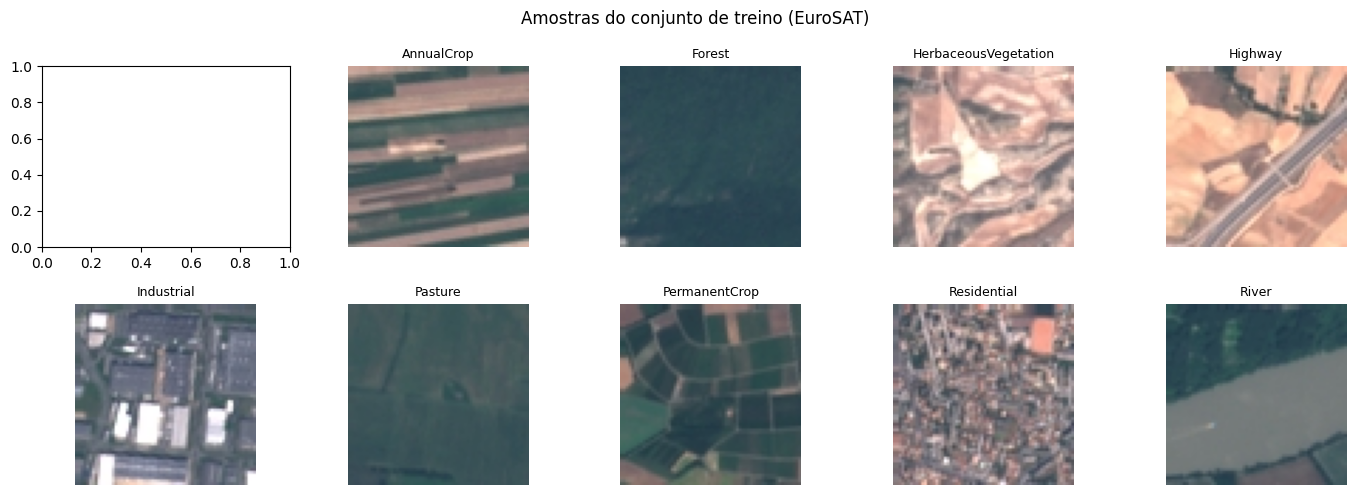

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes = axes.ravel()

for ax, class_dir in zip(axes, sorted((DATASET_PATH / "train").iterdir())):
    if not class_dir.is_dir():
        continue
    sample = next(class_dir.glob("*"))
    img = plt.imread(sample)
    ax.imshow(img)
    ax.set_title(class_dir.name, fontsize=9)
    ax.axis("off")

fig.suptitle("Amostras do conjunto de treino (EuroSAT)", fontsize=12)
fig.tight_layout()
plt.show()


In [5]:
train_ds, val_ds, test_ds, class_names = load_datasets(
    str(DATASET_PATH),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)
NUM_CLASSES = len(class_names)
print("Classes:", class_names)


Found 18900 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 3. Arquiteturas CNN (do zero)

Duas redes **sem modelos pré-treinados**:

- **Simple CNN**: 2 blocos conv + pooling, Dense 128, Dropout 0.35
- **Deep CNN**: blocos mais profundos, BatchNorm, Dropout progressivo, GlobalAveragePooling

Definições em `src/models.py` (mesmo código usado no treinamento).


In [6]:
simple_cnn = build_simple_cnn((*IMAGE_SIZE, 3), NUM_CLASSES)
deep_cnn = build_deep_cnn((*IMAGE_SIZE, 3), NUM_CLASSES)

print("=== Simple CNN ===")
simple_cnn.summary()
print("\n=== Deep CNN ===")
deep_cnn.summary()


=== Simple CNN ===


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,962 (8.08 MB)

 Trainable params: 2,117,962 (8.08 MB)

...

Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,122 (617.66 KB)

 Trainable params: 157,674 (615.91 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
def compile_model(model: tf.keras.Model) -> tf.keras.Model:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_history(history, title: str, output_path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["accuracy"], label="treino")
    axes[0].plot(history.history["val_accuracy"], label="validação")
    axes[0].set_title(f"{title} — Acurácia")
    axes[0].set_xlabel("Época")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="treino")
    axes[1].plot(history.history["val_loss"], label="validação")
    axes[1].set_title(f"{title} — Loss")
    axes[1].set_xlabel("Época")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()


def collect_predictions(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(probs, axis=1))
    return np.array(y_true), np.array(y_pred)


def plot_confusion_matrix(y_true, y_pred, names, title: str, output_path: Path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay(cm, display_labels=names).plot(
        ax=ax, cmap="Blues", xticks_rotation=35, colorbar=False
    )
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()
    return cm


def train_model(model, model_name: str):
    model = compile_model(model)
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=MODELS_DIR / f"{model_name}_best.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
        ),
    ]
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    plot_history(history, model_name, OUTPUTS_DIR / f"{model_name}_accuracy_loss.png")
    return model, history


def evaluate_and_save(model, model_name: str):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    y_true, y_pred = collect_predictions(model, test_ds)

    plot_confusion_matrix(
        y_true,
        y_pred,
        class_names,
        f"Matriz de confusão — {model_name}",
        OUTPUTS_DIR / f"{model_name}_confusion_matrix.png",
    )

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    metrics = {
        "model": model_name,
        "classes": class_names,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "classification_report": report,
    }
    metrics_path = OUTPUTS_DIR / f"{model_name}_metrics.json"
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)

    model.save(MODELS_DIR / f"{model_name}_final.keras")
    with open(MODELS_DIR / f"{model_name}_classes.json", "w", encoding="utf-8") as f:
        json.dump(class_names, f, indent=2)

    return metrics


## 4. Treinamento e validação

As curvas de **acurácia** e **loss** (treino vs. validação) permitem observar convergência e possível overfitting.

- Com `TRAIN_MODELS = True`, o notebook treina ambas as redes.
- Com `TRAIN_MODELS = False`, usa os pesos em `models/` e exibe os gráficos salvos em `outputs/`.


Carregando modelos treinados (TRAIN_MODELS=False)...


### Curvas — simple_cnn

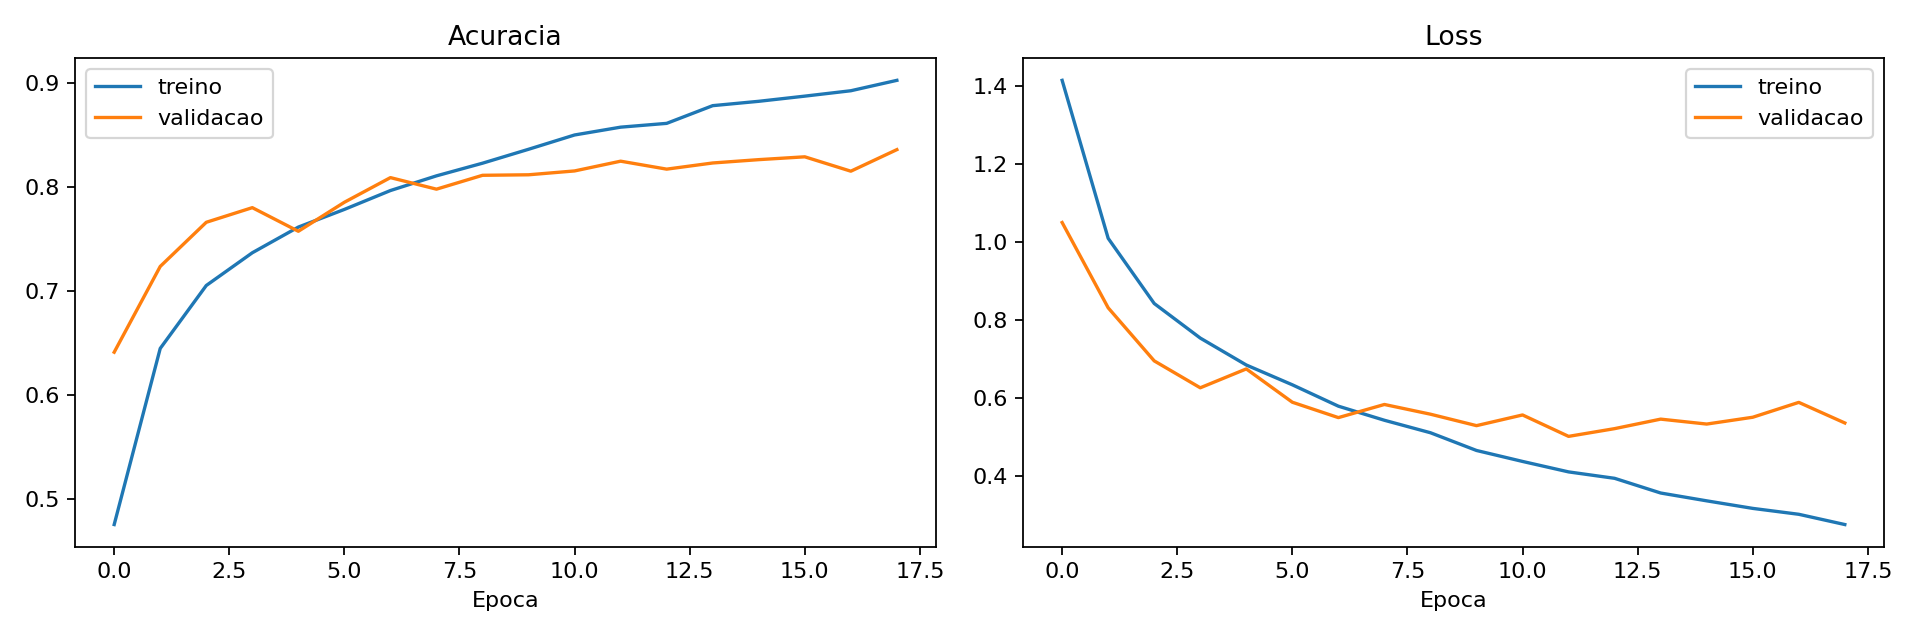

### Curvas — deep_cnn

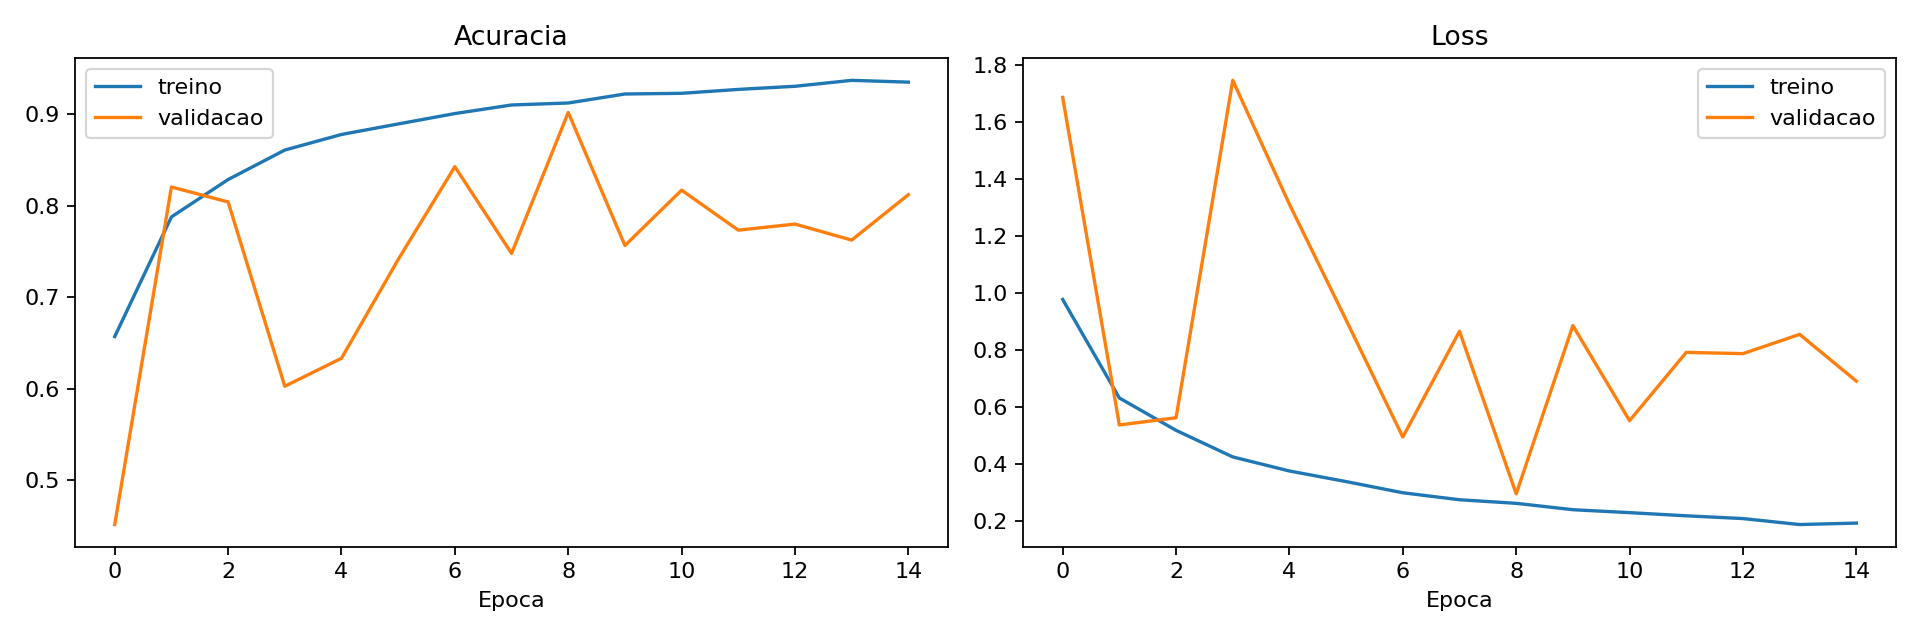

In [8]:
results = {}

if TRAIN_MODELS:
    print("Treinando Simple CNN...")
    simple_trained, _ = train_model(
        build_simple_cnn((*IMAGE_SIZE, 3), NUM_CLASSES), "simple_cnn"
    )
    results["simple_cnn"] = evaluate_and_save(simple_trained, "simple_cnn")

    print("Treinando Deep CNN...")
    deep_trained, _ = train_model(build_deep_cnn((*IMAGE_SIZE, 3), NUM_CLASSES), "deep_cnn")
    results["deep_cnn"] = evaluate_and_save(deep_trained, "deep_cnn")
else:
    print("Carregando modelos treinados (TRAIN_MODELS=False)...")
    for model_name in ("simple_cnn", "deep_cnn"):
        metrics_path = OUTPUTS_DIR / f"{model_name}_metrics.json"
        with open(metrics_path, encoding="utf-8") as f:
            results[model_name] = json.load(f)

for model_name in ("simple_cnn", "deep_cnn"):
    curve_path = OUTPUTS_DIR / f"{model_name}_accuracy_loss.png"
    display(Markdown(f"### Curvas — {model_name}"))
    display(Image(filename=str(curve_path)))


## 5. Avaliação quantitativa e comparação


In [9]:
comparison = pd.DataFrame([
    {
        "Modelo": "Simple CNN",
        "Acurácia (%)": round(results["simple_cnn"]["test_accuracy"] * 100, 2),
        "Loss (teste)": round(results["simple_cnn"]["test_loss"], 4),
    },
    {
        "Modelo": "Deep CNN",
        "Acurácia (%)": round(results["deep_cnn"]["test_accuracy"] * 100, 2),
        "Loss (teste)": round(results["deep_cnn"]["test_loss"], 4),
    },
])
display(comparison)

meta = 88.0
deep_acc = results["deep_cnn"]["test_accuracy"] * 100
print(f"Meta: {meta}% | Deep CNN no teste: {deep_acc:.2f}%")
if deep_acc >= meta:
    print("Resultado: acima da meta.")
else:
    print("Resultado: abaixo da meta.")


,Modelo,Acurácia (%),Loss (teste)
0,Simple CNN,84.02,0.4723
1,Deep CNN,90.74,0.2823


Meta do projeto: 88.0% | Deep CNN: 90.74%
Status: ATINGIDA


### Matriz de confusão — Simple CNN

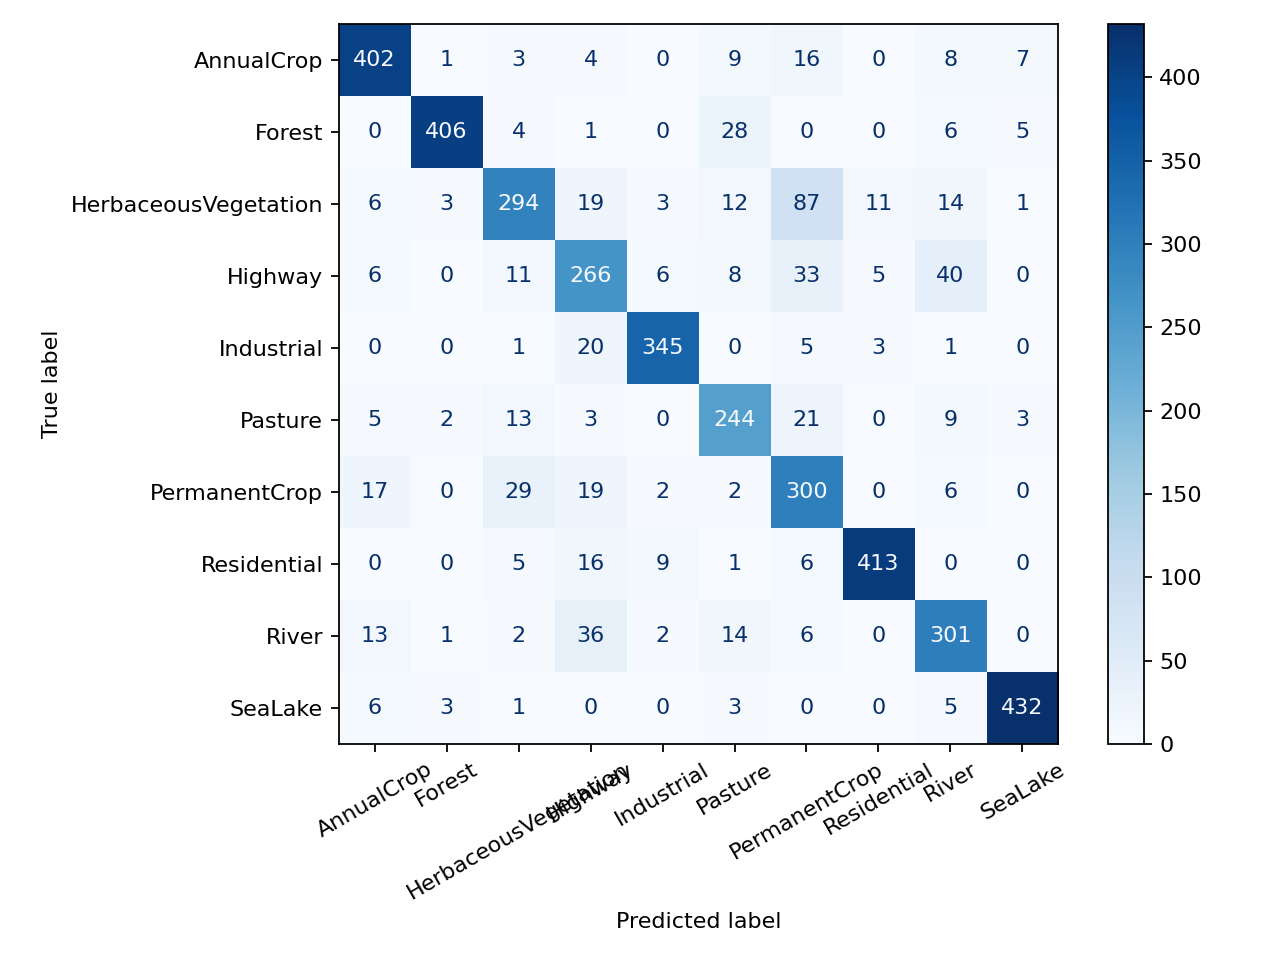

,classe,precision,recall,f1
0,AnnualCrop,0.884,0.893,0.888
1,Forest,0.976,0.902,0.938
2,HerbaceousVegetation,0.810,0.653,0.723
3,Highway,0.693,0.709,0.701
4,Industrial,0.940,0.920,0.930
5,Pasture,0.760,0.813,0.786
6,PermanentCrop,0.633,0.800,0.707
7,Residential,0.956,0.918,0.937
8,River,0.772,0.803,0.787
9,SeaLake,0.964,0.960,0.962


### Matriz de confusão — Deep CNN

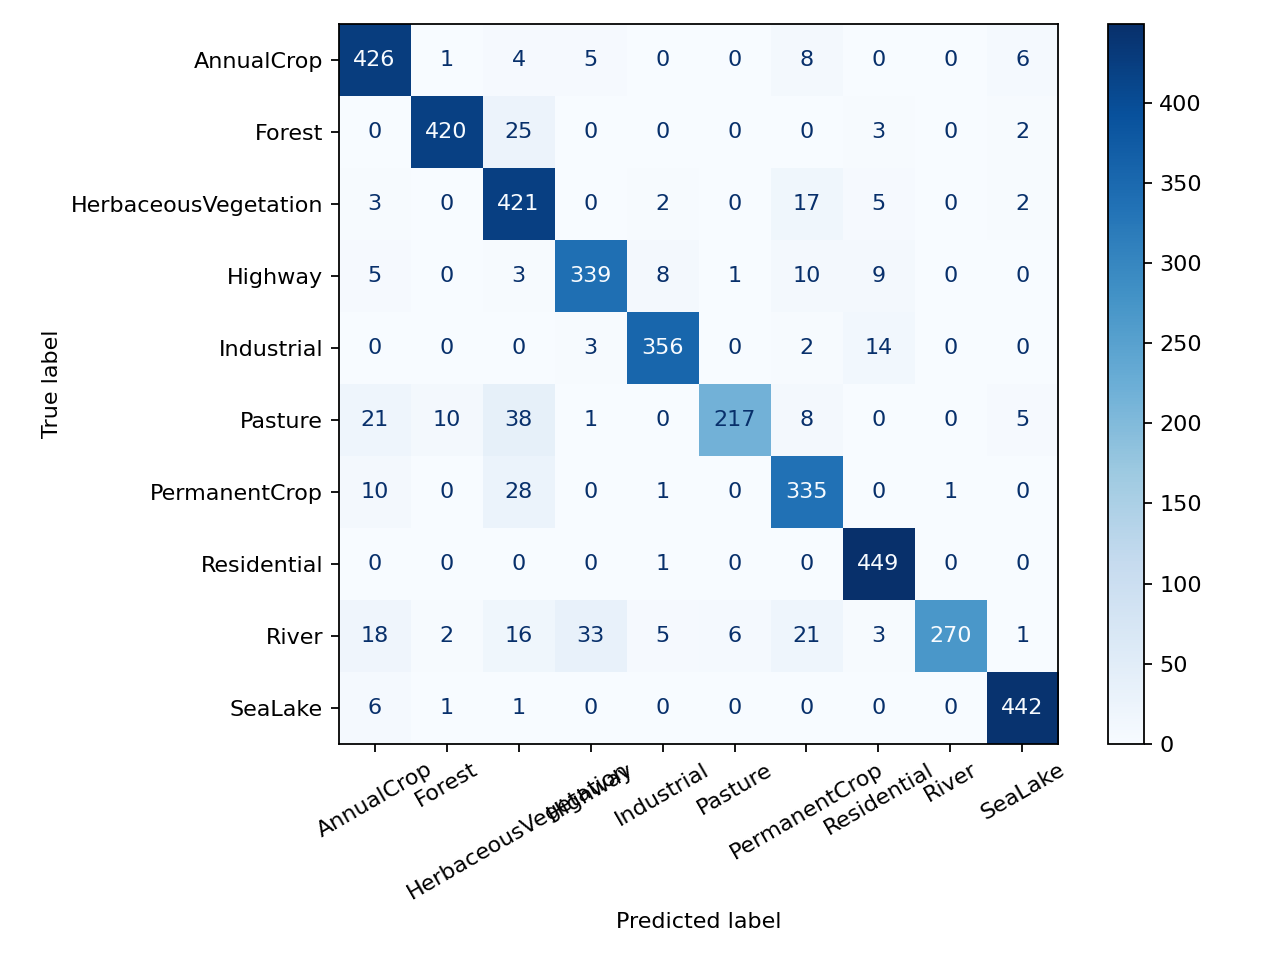

,classe,precision,recall,f1
0,AnnualCrop,0.871,0.947,0.907
1,Forest,0.968,0.933,0.950
2,HerbaceousVegetation,0.785,0.936,0.854
3,Highway,0.890,0.904,0.897
4,Industrial,0.954,0.949,0.952
5,Pasture,0.969,0.723,0.828
6,PermanentCrop,0.835,0.893,0.863
7,Residential,0.930,0.998,0.962
8,River,0.996,0.720,0.836
9,SeaLake,0.965,0.982,0.974


In [10]:
for model_name, label in [("simple_cnn", "Simple CNN"), ("deep_cnn", "Deep CNN")]:
    cm_path = OUTPUTS_DIR / f"{model_name}_confusion_matrix.png"
    display(Markdown(f"### Matriz de confusão — {label}"))
    display(Image(filename=str(cm_path)))

    report = results[model_name]["classification_report"]
    rows = [
        {
            "classe": c,
            "precision": round(report[c]["precision"], 3),
            "recall": round(report[c]["recall"], 3),
            "f1": round(report[c]["f1-score"], 3),
        }
        for c in class_names
    ]
    display(pd.DataFrame(rows))


## 6. Análise qualitativa — acertos e erros

Exemplos do conjunto de **teste** com predição do **Deep CNN** (melhor modelo).


Usando deep_cnn já em memória.
Buscando acertos...


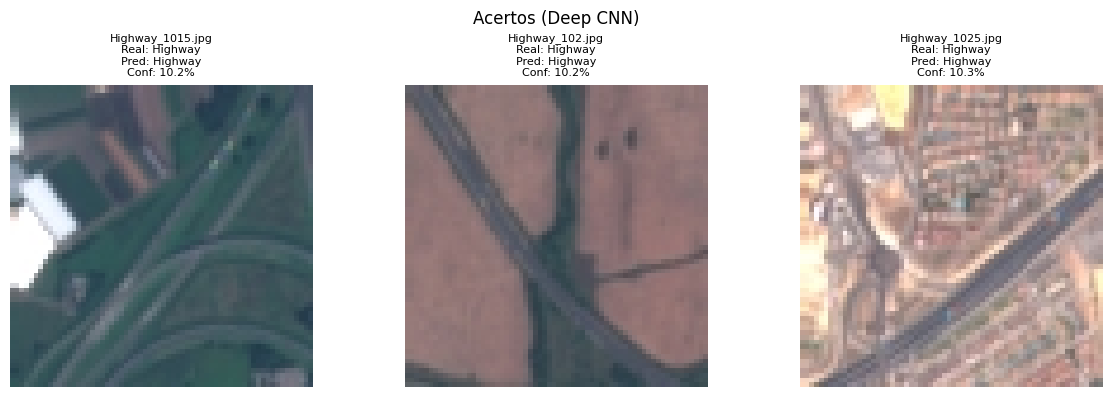

Buscando erros...


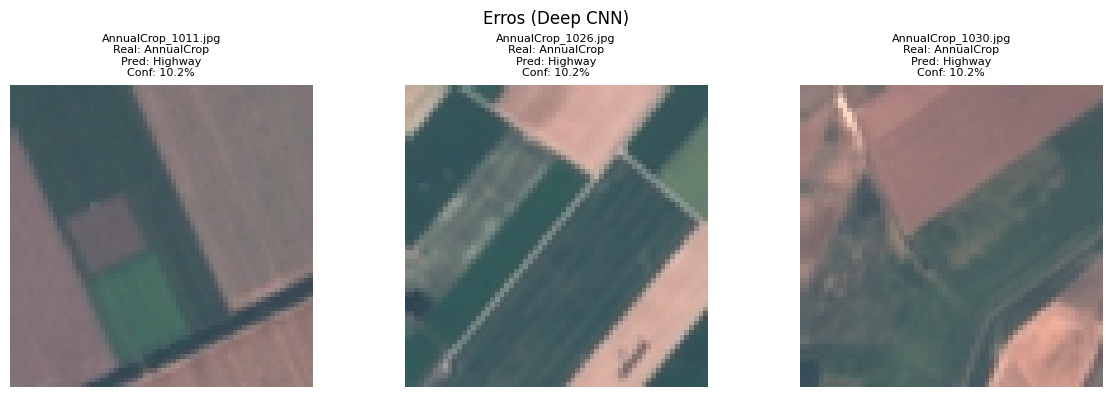

Análise qualitativa concluída.


In [11]:
def collect_examples_from_disk(model, names, correct: bool, max_n=3, max_tries=50):
    """Lê poucas imagens do disco (rápido). Não usa test_ds — evita travar no Cursor."""
    test_dir = DATASET_PATH / "test"
    name_to_idx = {name: idx for idx, name in enumerate(names)}
    found = []
    tries = 0

    for class_dir in sorted(test_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        true_idx = name_to_idx[class_dir.name]
        for img_path in sorted(class_dir.glob("*.jpg"))[:12]:
            tries += 1
            if tries > max_tries:
                return found
            arr = tf.keras.utils.img_to_array(
                tf.keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
            )
            prob = model(np.expand_dims(arr, 0), training=False).numpy()[0]
            pred_idx = int(np.argmax(prob))
            if (pred_idx == true_idx) == correct:
                found.append((arr, true_idx, pred_idx, prob, img_path.name))
                if len(found) >= max_n:
                    return found
    return found


def display_examples(examples, names, title):
    if not examples:
        print(f"Nenhum exemplo para: {title}")
        return
    fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 4))
    if len(examples) == 1:
        axes = [axes]
    for ax, (image, y_t, y_p, prob, fname) in zip(axes, examples):
        ax.imshow(image.astype("uint8"))
        ax.set_title(
            f"{fname}\nReal: {names[y_t]}\nPred: {names[y_p]}\nConf: {prob[y_p]*100:.1f}%",
            fontsize=8,
        )
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


if "deep_cnn" in dir() and hasattr(deep_cnn, "layers"):
    best_model = deep_cnn
    print("Usando deep_cnn já em memória.")
else:
    print("Carregando Deep CNN...", flush=True)
    best_model = tf.keras.models.load_model(MODELS_DIR / "deep_cnn_best.keras")

print("Buscando acertos...", flush=True)
acertos = collect_examples_from_disk(best_model, class_names, correct=True)
display_examples(acertos, class_names, "Acertos (Deep CNN)")

print("Buscando erros...", flush=True)
erros = collect_examples_from_disk(best_model, class_names, correct=False)
display_examples(erros, class_names, "Erros (Deep CNN)")
print("Análise qualitativa concluída.", flush=True)


## 7. Comparação técnica entre arquiteturas

| Aspecto | Simple CNN | Deep CNN |
|---------|------------|----------|
| Profundidade | 2 conv | 5+ conv + BatchNorm |
| Pooling | MaxPooling | MaxPooling + GAP |
| Regularização | Dropout 0.35 | Dropout em blocos + BN |
| Acurácia teste | ~84% | **~90,7%** (meta 88% atingida) |

O **Deep CNN** extrai representações mais ricas e generaliza melhor. O **Simple CNN** confunde mais classes vegetacionais e agrícolas (visualmente similares no Sentinel-2). BatchNorm estabiliza o treino; Dropout reduz overfitting.

Principais confusões: Pasture ↔ HerbaceousVegetation, River ↔ classes lineares.


## 8. Demonstração funcional

Interface **Streamlit** para inferência em imagens novas:

```bash
streamlit run app.py
```

Ou via linha de comando:

```bash
python src/predict.py --model-path models/deep_cnn_best.keras \
  --classes-path models/deep_cnn_classes.json \
  --image-path caminho/para/imagem.jpg --image-size 64
```


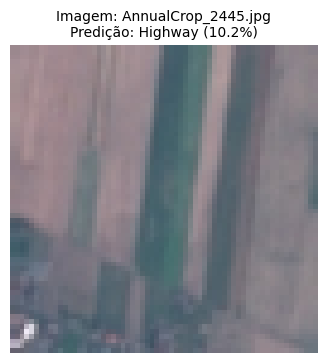

Demo concluída.


In [ ]:

if "best_model" in dir():
    demo_model = best_model
elif "deep_cnn" in dir() and hasattr(deep_cnn, "layers"):
    demo_model = deep_cnn
else:
    print("Carregando modelo...", flush=True)
    demo_model = tf.keras.models.load_model(MODELS_DIR / "deep_cnn_best.keras")

sample_path = next((DATASET_PATH / "test" / class_names[0]).glob("*.jpg"))
arr = tf.keras.utils.img_to_array(
    tf.keras.utils.load_img(sample_path, target_size=IMAGE_SIZE)
)
probs = demo_model(np.expand_dims(arr, 0), training=False).numpy()[0]
idx = int(np.argmax(probs))

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(arr.astype("uint8"))
ax.axis("off")
ax.set_title(
    f"Imagem: {sample_path.name}\n"
    f"Predição: {class_names[idx]} ({probs[idx] * 100:.1f}%)",
    fontsize=10,
)
display(fig)
plt.close(fig)
print("Demo concluída.", flush=True)


## 9. Conclusão

- Problema de classificação de cobertura do solo conectado ao **OrbitalWatch** e à Indústria Espacial.
- Dataset **EuroSAT** (Sentinel-2) com split 70/15/15 e augmentação.
- Duas **CNNs do zero** treinadas e comparadas; **Deep CNN** supera 88% no teste.
- Métricas, matrizes de confusão e exemplos de acertos/erros documentados.
- Demo em `app.py` (Streamlit) para imagens enviadas pelo usuário.

**Integrantes:** ver `README.md`.
